# Taller 1

**MINE-4101: Ciencia de Datos Aplicada**
**Universidad de los Andes — Semestre 2026-20**

**Nombre:** Samuel Charry Tobar  | Sergio Perez

**Código:** 202313509 | 202314506

El notebook sigue los cuatro puntos del enunciado: entendimiento de los datos, estrategia, desarrollo y recomendaciones.

In [1]:
# librerías que usamos en el taller
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [2]:
# cargamos la base desde el archivo parquet
from pathlib import Path
import sys

ARCHIVO = "secop_bienes.parquet"
EN_COLAB = "google.colab" in sys.modules

# Buscamos el archivo junto al notebook, en data/ o en /content (Colab)
carpetas = [Path.cwd(), Path.cwd() / "data", Path.cwd().parent, Path("/content"), Path("/content/data")]
ruta = next((c / ARCHIVO for c in carpetas if (c / ARCHIVO).exists()), None)

if ruta is None and EN_COLAB:
    # En Colab el entorno arranca vacío: pedimos subir el archivo
    from google.colab import files
    print(f"Sube {ARCHIVO}")
    subidos = files.upload()
    if ARCHIVO in subidos:
        ruta = Path("/content") / ARCHIVO
    elif subidos:
        ruta = Path("/content") / next(iter(subidos))

if ruta is None:
    raise FileNotFoundError(f"No se encontró {ARCHIVO}. Colócalo en la misma carpeta del notebook o en data/.")

raw_df = pd.read_parquet(ruta)
print(ruta)
raw_df.shape


C:\Users\sergi\Downloads\taller1\secop_bienes.parquet


(196391, 36)

## 1. Entendimiento inicial de los datos

Primero revisamos qué columnas trae la base, de qué tipo son y si hay datos raros.

In [3]:
# primeras filas de la base
raw_df.head()

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de p...,2019-06-19,2019-06-18,2019-12-31,No definido,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,No Definido,CO,17897916.0,17896237,17896237,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDOR...,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,390000000.0,389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CA...,2019-06-18,2019-06-24,2019-09-30,No definido,DAP - Entregado en un punto (lugar de destino ...,FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,11970000.0,11970000,11970000,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,V1.41115300,ADQUISICIÓN DE UN SISTEMA DE SONAR 3D DE ALTA ...,2019-07-25,2019-07-12,2019-11-30,Dia(s),Como acordado previamente,CASCO ANTIGUO,76044753,No,No,Otro,CO,733992000.0,0,0,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.92121701,Suministro de equipos para la instalación de t...,2019-11-01,2019-06-17,2019-12-30,No definido,No Definido,hr technology sas,900815825,Si,No,No Definido,CO,6000000.0,0,0,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...


In [4]:
# tipos de dato y nulos por columna
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196391 entries, 0 to 196390
Data columns (total 36 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id_contrato                       196391 non-null  object        
 1   nombre_entidad                    196391 non-null  object        
 2   departamento                      196391 non-null  object        
 3   ciudad                            196391 non-null  object        
 4   orden                             196391 non-null  object        
 5   sector                            196391 non-null  object        
 6   rama                              196391 non-null  object        
 7   entidad_centralizada              196391 non-null  object        
 8   tipo_de_contrato                  196391 non-null  object        
 9   modalidad_de_contratacion         196391 non-null  object        
 10  codigo_de_categoria_principal   

La base tiene 196.391 contratos y 36 columnas. La mayoría son texto (`object`); las fechas y los valores en pesos ya vienen con el tipo correcto.

En el `head()` se ve que varias columnas usan "No Definido" en vez de un nulo y que `estado_contrato` tiene valores en minúscula.

In [5]:
# columnas con más nulos
raw_df.isna().sum().sort_values(ascending=False).head(6)

fecha_de_inicio_del_contrato        2440
documento_proveedor                    4
es_pyme                                0
g_nero_representante_legal             0
nacionalidad_representante_legal       0
valor_del_contrato                     0
dtype: int64

In [6]:
# número de valores únicos por columna
raw_df.nunique().sort_values()

liquidaci_n                              2
es_pyme                                  2
es_grupo                                 2
obligaci_n_ambiental                     2
entidad_centralizada                     2
tipo_de_contrato                         2
el_contrato_puede_ser_prorrogado         2
origen_de_los_recursos                   2
habilita_pago_adelantado                 3
orden                                    4
g_nero_representante_legal               4
destino_gasto                            4
rama                                     5
modalidad_de_contratacion                9
estado_contrato                          9
sector                                  26
nacionalidad_representante_legal        30
condiciones_de_entrega                  31
departamento                            34
dias_adicionados                       380
ciudad                                 676
duraci_n_del_contrato                  835
fecha_de_firma                        2437
fecha_de_in

Casi no hay nulos (solo en `fecha_de_inicio_del_contrato` y 4 en `documento_proveedor`). Por el número de valores únicos se ven tres tipos de columnas: categóricas con pocas categorías (modalidad, destino del gasto, estado, etc.), texto libre o identificadores que no usamos, y las numéricas (valores en pesos y `dias_adicionados`).

Tambien identificamos algo raro con el tipo estadístico: `id_contrato` y `documento_proveedor` parecen números pero son identificadores. `dias_adicionados` es cuantitativa discreta y los valores en pesos son continuos.

Como hay textos tipo "No Definido", contamos cuántos hay por columna.

In [7]:
# contamos textos que en realidad son faltantes ("No definido", "No aplica", etc.)
faltantes_texto = {}
for col in raw_df.select_dtypes("object").columns:
    valores = raw_df[col].astype(str).str.strip().str.lower()
    n = valores.isin(["no definido", "no aplica", "sin definir", ""]).sum()
    if n > 0:
        faltantes_texto[col] = n

pd.Series(faltantes_texto).sort_values(ascending=False)

condiciones_de_entrega              49971
ciudad                              41672
g_nero_representante_legal          35822
habilita_pago_adelantado            28507
duraci_n_del_contrato                9490
departamento                         7510
documento_proveedor                  1565
objeto_del_contrato                  1109
destino_gasto                         911
nacionalidad_representante_legal      869
proveedor_adjudicado                  121
orden                                   9
sector                                  9
rama                                    9
dtype: int64

Hay bastantes faltantes escondidos en columnas como ciudad o condiciones de entrega, pero en `destino_gasto` son pocos (911), así que no afectan. Las columnas con muchos faltantes no las usamos.

In [8]:
# conteo de categorías de algunas variables
for col in ["orden", "tipo_de_contrato", "destino_gasto", "liquidaci_n", "estado_contrato"]:
    print(raw_df[col].value_counts(dropna=False), "\n")

orden
Territorial             97293
Nacional                96680
Corporación Autónoma     2409
No Definido                 9
Name: count, dtype: int64 

tipo_de_contrato
Suministros    106632
Compraventa     89759
Name: count, dtype: int64 

destino_gasto
Funcionamiento    117097
Inversión          78383
No aplica            532
No Definido          379
Name: count, dtype: int64 

liquidaci_n
No    118418
Si     77973
Name: count, dtype: int64 

estado_contrato
terminado       54230
En ejecución    51441
Cerrado         46824
Modificado      34462
Aprobado         9211
Suspendido        153
cedido             43
Cancelado          26
Borrador            1
Name: count, dtype: int64 



In [9]:
# contratos por sector
raw_df["sector"].value_counts()

sector
Servicio Público                                      37390
defensa                                               34585
No aplica/No pertenece                                24465
Salud y Protección Social                             22037
Ley de Justicia                                       20377
Trabajo                                               14759
Educación Nacional                                    10231
Ambiente y Desarrollo Sostenible                       8109
Transporte                                             4655
Cultura                                                2792
deportes                                               2610
Hacienda y Crédito Público                             2441
Industria                                              1807
Vivienda, Ciudad y Territorio                          1497
Planeación                                             1319
agricultura                                            1254
interior                         

Algunas categorías de `sector` ("defensa", "deportes", "interior", "agricultura") y de `estado_contrato` ("terminado", "cedido") vienen en minúscula. No hay duplicados, pero en la limpieza las dejamos todas con el mismo formato.

También miramos dos columnas que se veían desordenadas.

In [10]:
# valores más comunes de la duración del contrato
raw_df["duraci_n_del_contrato"].value_counts().head(15)

duraci_n_del_contrato
30 Dia(s)      13938
1 Mes(es)      12371
Dia(s)         11327
2 Mes(es)      10452
15 Dia(s)      10442
No definido     9490
3 Mes(es)       7937
10 Dia(s)       7730
4 Mes(es)       5748
5 Dia(s)        5712
60 Dia(s)       5635
20 Dia(s)       5129
6 Mes(es)       5036
45 Dia(s)       4613
5 Mes(es)       4202
Name: count, dtype: int64

In [11]:
# valores más comunes de las condiciones de entrega
raw_df["condiciones_de_entrega"].value_counts().head(15)

condiciones_de_entrega
No Definido                                                   49971
Como acordado previamente                                     33678
NXTWY.DLVY.2                                                  32989
A convenir                                                    31885
NXTWY.DLVY.6                                                  31636
Transporte incluido                                            7837
NXTWY.DLVY.3                                                   6051
DAP - Entregado en un punto (lugar de destino convenido)        862
NXTWY.DLVY.12                                                   614
Transporte no incluído                                          204
NXTWY.DLVY.4                                                    146
Transporte a cargo del comprador                                125
CPT - Transporte pagado hasta (lugar de destino convenido)       86
NXTWY.DLVY.5                                                     81
NXTWY.DLVY.8             

`duraci_n_del_contrato` mezcla días, meses y textos, y `condiciones_de_entrega` tiene códigos raros ("NXTWY..."). No son importantes para la pregunta, así que no las usamos.

Ahora las variables numéricas.

In [12]:
# estadísticas descriptivas de las variables numéricas
cols_valor = ["valor_del_contrato", "valor_pagado", "valor_facturado", "valor_pendiente_de_pago", "dias_adicionados"]
raw_df[cols_valor].describe().T

,count,mean,std,min,25%,50%,75%,max
valor_del_contrato,196391.0,6.582426e+10,2.901535e+13,0.0,12021214.0,33600000.0,100000000.0,1.285845e+16
valor_pagado,196391.0,1.194911e+08,2.444116e+09,0.0,0.0,0.0,28120772.5,5.944034e+11
valor_facturado,196391.0,1.484092e+08,2.969810e+09,0.0,0.0,3207328.0,37086225.0,5.945032e+11
valor_pendiente_de_pago,196391.0,6.570476e+10,2.901535e+13,-84184884.0,0.0,6717571.0,42411892.0,1.285845e+16
dias_adicionados,196391.0,5.107485e+00,4.066243e+01,0.0,0.0,0.0,0.0,1.427600e+04


Se ven varios problemas: el valor máximo de un contrato es del orden de 10^16 pesos (imposible), hay contratos con valor 0, el saldo pendiente tiene negativos y hay un contrato con 14.276 días adicionados. Además la media está muy lejos de la mediana, o sea que hay colas largas.

Revisamos también las fechas.

In [13]:
# contratos firmados por año
raw_df["fecha_de_firma"].dt.year.value_counts().sort_index()

fecha_de_firma
2019    16425
2020    20135
2021    24043
2022    28070
2023    32971
2024    34634
2025    40113
Name: count, dtype: int64

In [14]:
# rango de las fechas de firma y de fin
print("firma:", raw_df["fecha_de_firma"].min(), "a", raw_df["fecha_de_firma"].max())
print("fin:  ", raw_df["fecha_de_fin_del_contrato"].min(), "a", raw_df["fecha_de_fin_del_contrato"].max())

firma: 2019-01-01 00:00:00 a 2025-12-31 00:00:00
fin:   0202-12-31 00:00:00 a 2065-01-31 00:00:00


Hay contratos de 2019 a 2025 y cada año hay más (de 16 mil a 40 mil). La fecha de fin tiene años imposibles (desde el año 202 hasta 2065), seguramente por errores de digitación.

### Variables principales

Escogimos cinco variables:

- `valor_del_contrato`: cuánto cuesta el contrato.
- `modalidad_de_contratacion`: cómo se escogió al proveedor.
- `destino_gasto`: funcionamiento o inversión.
- `dias_adicionados`: si se amplió el plazo (la desviación más fácil de medir).
- `valor_pagado`: para ver cuánto se ejecutó.

Las tres primeras se conocen al firmar el contrato y las dos últimas muestran qué pasó después.

In [15]:
# estadísticas univariadas de las variables numéricas principales
top5_num = ["valor_del_contrato", "valor_pagado", "dias_adicionados"]

univariado = raw_df[top5_num].agg(["count", "mean", "median", "std", "min", "max"]).T
univariado["IQR"] = raw_df[top5_num].quantile(0.75) - raw_df[top5_num].quantile(0.25)
univariado["asimetria"] = raw_df[top5_num].skew()
univariado["curtosis"] = raw_df[top5_num].kurtosis()
univariado.round(2)

,count,mean,median,std,min,max,IQR,asimetria,curtosis
valor_del_contrato,196391.0,6.582426e+10,33600000.0,2.901535e+13,0.0,1.285845e+16,87978786.0,443.16,196390.95
valor_pagado,196391.0,1.194911e+08,0.0,2.444116e+09,0.0,5.944034e+11,28120772.5,168.35,36616.26
dias_adicionados,196391.0,5.110000e+00,0.0,4.066000e+01,0.0,1.427600e+04,0.0,222.19,77269.88


Las tres variables tienen colas muy largas (asimetría de 443 en el valor). La mediana del valor es 33,6 millones pero la media es 65.824 millones por culpa de unos pocos valores extremos, por eso usamos la mediana. En `valor_pagado` y `dias_adicionados` la mediana es 0.

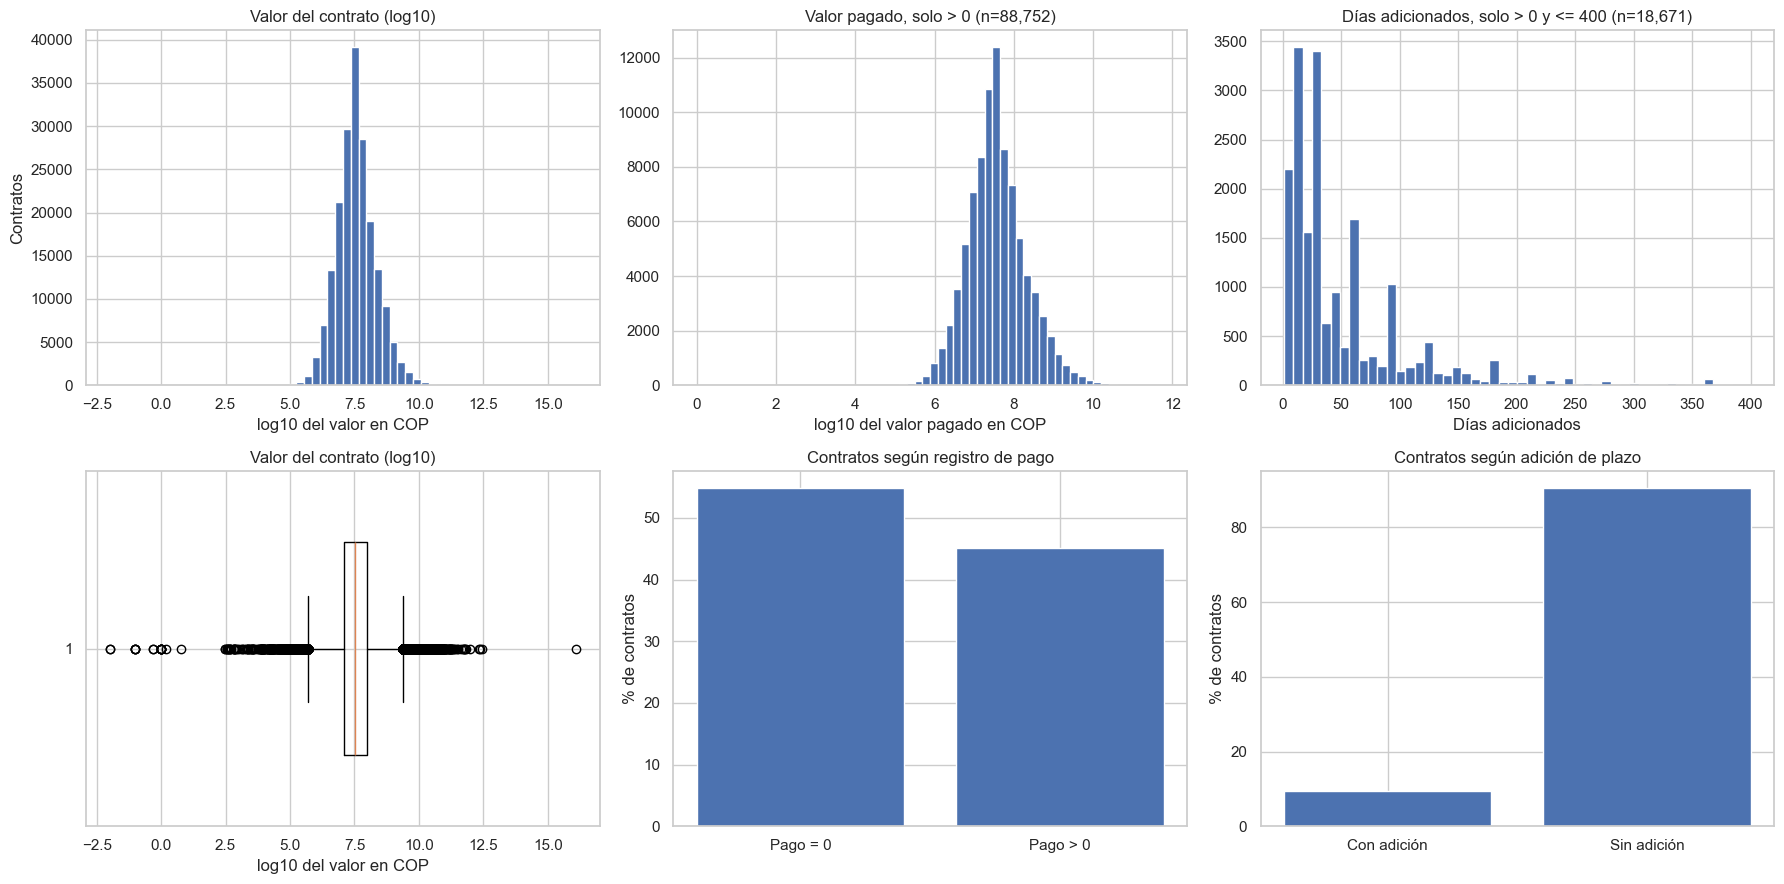

Contratos con valor_pagado = 0: 54.81%
Contratos con dias_adicionados > 0: 9.51%


In [16]:
# histogramas, boxplot y proporciones de las variables numéricas principales
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

valor_pos = raw_df.loc[raw_df["valor_del_contrato"] > 0, "valor_del_contrato"]
axes[0, 0].hist(np.log10(valor_pos), bins=60)
axes[0, 0].set_title("Valor del contrato (log10)")
axes[0, 0].set_xlabel("log10 del valor en COP")
axes[0, 0].set_ylabel("Contratos")

axes[1, 0].boxplot(np.log10(valor_pos), orientation="horizontal", widths=0.6)
axes[1, 0].set_title("Valor del contrato (log10)")
axes[1, 0].set_xlabel("log10 del valor en COP")

pago_pos = raw_df.loc[raw_df["valor_pagado"] > 0, "valor_pagado"]
axes[0, 1].hist(np.log10(pago_pos), bins=60)
axes[0, 1].set_title(f"Valor pagado, solo > 0 (n={len(pago_pos):,})")
axes[0, 1].set_xlabel("log10 del valor pagado en COP")

pct_cero = (raw_df["valor_pagado"] == 0).mean() * 100
axes[1, 1].bar(["Pago = 0", "Pago > 0"], [pct_cero, 100 - pct_cero])
axes[1, 1].set_title("Contratos según registro de pago")
axes[1, 1].set_ylabel("% de contratos")

adic = raw_df.loc[raw_df["dias_adicionados"] > 0, "dias_adicionados"]
axes[0, 2].hist(adic[adic <= 400], bins=50)
axes[0, 2].set_title(f"Días adicionados, solo > 0 y <= 400 (n={len(adic):,})")
axes[0, 2].set_xlabel("Días adicionados")

pct_adic = (raw_df["dias_adicionados"] > 0).mean() * 100
axes[1, 2].bar(["Con adición", "Sin adición"], [pct_adic, 100 - pct_adic])
axes[1, 2].set_title("Contratos según adición de plazo")
axes[1, 2].set_ylabel("% de contratos")

plt.tight_layout()
plt.show()

print(f"Contratos con valor_pagado = 0: {pct_cero:.2f}%")
print(f"Contratos con dias_adicionados > 0: {pct_adic:.2f}%")

Usamos log10 porque sin eso no se ve nada en los histogramas. El 54,81% de los contratos tiene pago en 0 y solo el 9,51% tuvo adición de plazo.

modalidad_de_contratacion
Mínima cuantía                                                 59.96
Selección abreviada subasta inversa                            16.76
Contratación régimen especial                                   9.80
Selección Abreviada de Menor Cuantía                            4.49
Contratación régimen especial (con ofertas)                     3.13
Contratación Directa (con ofertas)                              2.55
Contratación directa                                            2.01
Licitación pública                                              1.19
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes     0.12
Name: proportion, dtype: float64 

destino_gasto
Funcionamiento    59.62
Inversión         39.91
No aplica          0.27
No Definido        0.19
Name: proportion, dtype: float64 



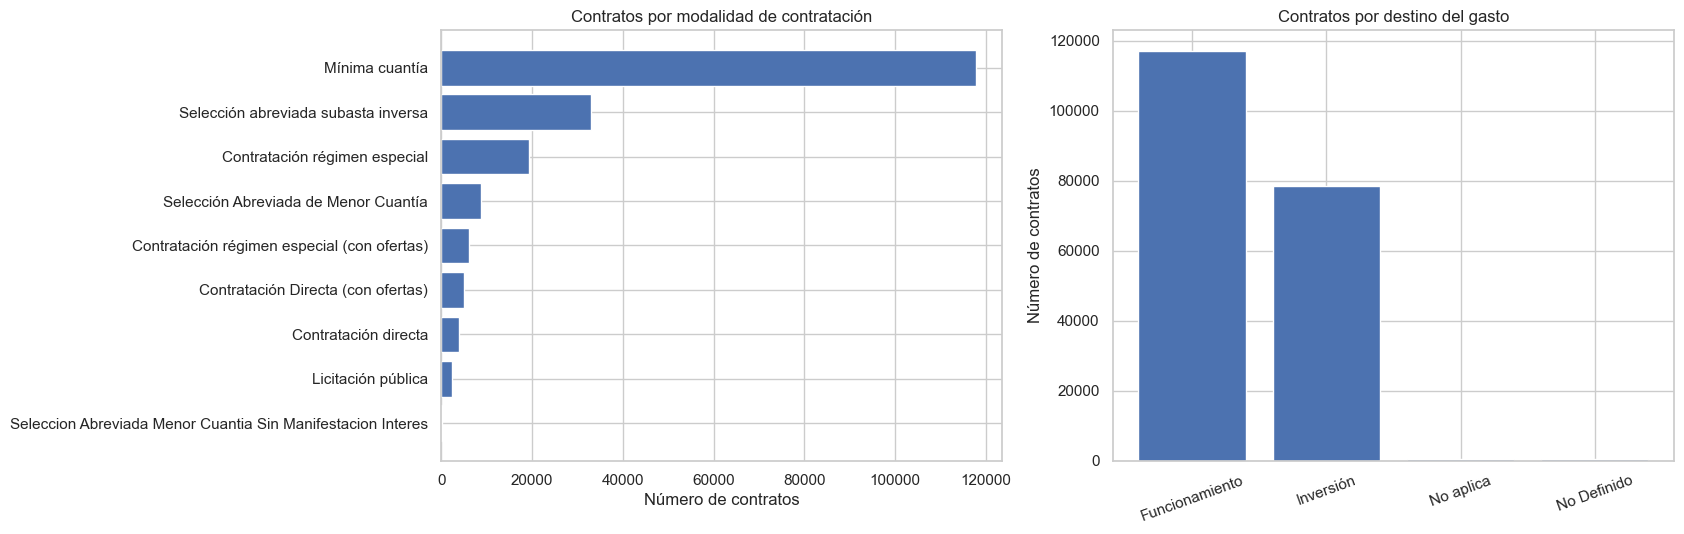

In [17]:
# distribución de la modalidad y del destino del gasto
for columna in ["modalidad_de_contratacion", "destino_gasto"]:
    print(raw_df[columna].value_counts(normalize=True).mul(100).round(2), "\n")

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

conteo_mod = raw_df["modalidad_de_contratacion"].value_counts()
axes[0].barh(conteo_mod.index[::-1], conteo_mod.values[::-1])
axes[0].set_title("Contratos por modalidad de contratación")
axes[0].set_xlabel("Número de contratos")

conteo_dest = raw_df["destino_gasto"].value_counts()
axes[1].bar(conteo_dest.index, conteo_dest.values)
axes[1].set_title("Contratos por destino del gasto")
axes[1].set_ylabel("Número de contratos")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Mínima cuantía es casi el 60% de los contratos y subasta inversa el 16,76%. Licitación pública es solo el 1,19%. En destino del gasto, 59,62% es funcionamiento y 39,91% inversión.

### Problemas de calidad de datos

Contamos los problemas que vimos. La limpieza se hace sobre una copia (`df`) para no modificar `raw_df`.

In [18]:
# contamos los problemas de calidad en los valores
terminados_raw = raw_df["estado_contrato"].str.lower().isin(["terminado", "cerrado"])
diferencia_valores = (raw_df["valor_del_contrato"] - raw_df["valor_pagado"] - raw_df["valor_pendiente_de_pago"]).abs()

print("Terminados o cerrados con pago 0:   ", (terminados_raw & (raw_df["valor_pagado"] == 0)).sum())
print("Valor != pagado + pendiente:        ", (diferencia_valores >= 1).sum())
print("Pagado > valor del contrato:        ", (raw_df["valor_pagado"] > raw_df["valor_del_contrato"]).sum())
print("Saldo pendiente negativo:           ", (raw_df["valor_pendiente_de_pago"] < 0).sum())
print("Valor del contrato <= 0:            ", (raw_df["valor_del_contrato"] <= 0).sum())
print("Valor del contrato > 1 billón:      ", (raw_df["valor_del_contrato"] > 1e12).sum())
print("Más de 730 días adicionados:        ", (raw_df["dias_adicionados"] > 730).sum())

Terminados o cerrados con pago 0:    42795
Valor != pagado + pendiente:         9450
Pagado > valor del contrato:         177
Saldo pendiente negativo:            144
Valor del contrato <= 0:             188
Valor del contrato > 1 billón:       4
Más de 730 días adicionados:         4


In [19]:
# contamos las fechas de fin imposibles
anio_fin = raw_df["fecha_de_fin_del_contrato"].dt.year
print("Fecha de fin fuera de 2015-2030:", ((anio_fin < 2015) | (anio_fin > 2030)).sum())
print("Fecha de fin antes de la firma: ", (raw_df["fecha_de_fin_del_contrato"] < raw_df["fecha_de_firma"]).sum())

Fecha de fin fuera de 2015-2030: 21
Fecha de fin antes de la firma:  2601


Miramos los contratos más caros para decidir dónde cortar.

In [20]:
# los 6 contratos más caros y cuántos pasan cada umbral
evidencia = raw_df.nlargest(6, "valor_del_contrato")[
    ["valor_del_contrato", "valor_pagado", "nombre_entidad", "objeto_del_contrato"]
].copy()
evidencia["objeto_del_contrato"] = evidencia["objeto_del_contrato"].str.slice(0, 90)
evidencia["valor_del_contrato"] = evidencia["valor_del_contrato"].map(lambda v: f"{v:,.0f}")
evidencia["valor_pagado"] = evidencia["valor_pagado"].map(lambda v: f"{v:,.0f}")
print(evidencia.to_string(index=False))

print()
for umbral in [1e11, 5e11, 1e12]:
    print(f"Contratos por encima de {umbral:,.0f}: {(raw_df['valor_del_contrato'] > umbral).sum()}")

    valor_del_contrato    valor_pagado                                           nombre_entidad                                                                         objeto_del_contrato
12,858,450,316,000,000               0 INSTITUTO MUNICIPAL DEL DEPORTE Y LA RECREACION DE YUMBO  ADQUISICION A TITULO DE COMPRAVENTA DE TRES (3) MAQUINAS: DOS TRACTORES CORTA CESPED DE 23
     2,846,224,257,835               0      MINISTERIO DE COMERCIO INDUSTRIA Y TURISMO - MINCIT  ENTREGAR A TÍTULO DE ARRENDAMIENTO EL PREDIO Y LAS  CONSTRUCCIONES DE PROPIEDAD DEL MINIST
     2,385,617,800,000   2,385,617,800                                    GOBERNACIÓN DE BOYACÁ SUMINISTRO DE ELEMENTOS Y EQUIPOS PARA ALMACENAMIENTO\nDE AGUA Y RIEGO INTRAPREDIAL MEDIANT
     2,115,000,000,000               0                            PERSONERIA  DE VITERBO CALDAS                                                                                 No definido
       934,139,777,361 370,934,288,432                      

Los cuatro contratos por encima de un billón no tienen sentido (por ejemplo, 12.858 billones por tres cortacéspedes), mientras que el de 934 mil millones del Ejército es alimentación para tropas y sí puede ser real. Por eso cortamos en un billón.

Qué hicimos con cada problema:

- **Valor <= 0 (188) o mayor a un billón (4):** se eliminan (192 registros, 0,1%).
- **Terminados con pago en 0 (42.795):** probablemente el pago no se reportó; no los contamos como subejecución.
- **Pagado mayor al valor (177) y pendiente negativo (144):** se excluyen al calcular la ejecución.
- **Valor distinto a pagado + pendiente (9.450):** no sabemos cuál columna está mal, se deja así.
- **Más de 730 días adicionados (4):** se dejan, porque solo usamos si hubo adición o no.
- **Fechas imposibles (21 fuera de rango y 2.601 con fin antes de la firma):** se marcan con una columna.
- **Categorías en minúscula:** se pasan a formato título.
- **Duración y condiciones de entrega:** no se usan.

In [21]:
# limpieza: formato de categorías, valores imposibles y marca de fechas raras
df = raw_df.copy()

# unificar mayúsculas en las categorías
df["sector"] = df["sector"].str.strip().str.title()
df["estado_contrato"] = df["estado_contrato"].str.strip().str.title()

# quitar valores imposibles
n_inicial = len(df)
df = df[(df["valor_del_contrato"] > 0) & (df["valor_del_contrato"] < 1e12)].copy()
print(f"Eliminados: {n_inicial - len(df)}  |  quedan {len(df):,} ({100 * len(df) / n_inicial:.2f}%)")

# marcar fechas raras sin borrarlas
df["fecha_inconsistente"] = (
    (df["fecha_de_fin_del_contrato"] < df["fecha_de_firma"])
    | (df["fecha_de_fin_del_contrato"].dt.year < 2015)
    | (df["fecha_de_fin_del_contrato"].dt.year > 2030)
)
print("Con fechas inconsistentes:", df["fecha_inconsistente"].sum())

df["anio_firma"] = df["fecha_de_firma"].dt.year

Eliminados: 192  |  quedan 196,199 (99.90%)
Con fechas inconsistentes: 2613


In [22]:
# revisamos que la limpieza quedó bien
print(df["sector"].nunique(), "sectores (antes", raw_df["sector"].nunique(), ")")
print(df["estado_contrato"].value_counts())

26 sectores (antes 26 )
estado_contrato
Terminado       54154
En Ejecución    51417
Cerrado         46762
Modificado      34441
Aprobado         9202
Suspendido        153
Cedido             43
Cancelado          26
Borrador            1
Name: count, dtype: int64


## 2. Estrategia de análisis

A partir del enunciado definimos tres desviaciones: adición de plazo, subejecución (se pagó menos del 95% del valor) y contrato terminado sin liquidar. La principal es la adición de plazo porque está en todos los contratos; las otras solo se pueden medir en contratos terminados. Antes de comparar revisamos los indicadores por año para escoger un periodo comparable, y luego calculamos tasas y medianas por modalidad, valor, destino del gasto y sector.

Después planteamos hipótesis y usamos la prueba según el tipo de variable: chi-cuadrado para modalidad vs adición, Mann-Whitney para valor vs adición, Kruskal-Wallis para la ejecución por destino y sector, y Pearson/Spearman para valor vs días adicionados. Usamos pruebas no paramétricas porque los datos no son normales, y como la base es muy grande (casi todo sale significativo) también miramos el tamaño del efecto. Para las gráficas usamos boxplots, tasas por decil y un mapa de calor de modalidad por cuartil de valor. Al final armamos segmentos combinando los factores más importantes.

## 3. Desarrollo del análisis

### 3.1 Indicadores de desviación

In [23]:
# creamos los indicadores de desviación de cada contrato
df["adicion_plazo"] = df["dias_adicionados"] > 0
df["ejecucion_terminada"] = df["estado_contrato"].isin(["Terminado", "Cerrado"])

# el pago en 0 va aparte porque probablemente es un faltante
df["sin_registro_pago"] = df["ejecucion_terminada"] & (df["valor_pagado"] == 0)
df["sin_liquidar"] = df["ejecucion_terminada"] & (df["liquidaci_n"] == "No")

calculable = (
    df["ejecucion_terminada"]
    & (df["valor_pagado"] > 0)
    & (df["valor_pagado"] <= df["valor_del_contrato"])
)
df["razon_ejecucion"] = np.where(calculable, df["valor_pagado"] / df["valor_del_contrato"], np.nan)
df["subejecucion"] = df["razon_ejecucion"] < 0.95

n_term = df["ejecucion_terminada"].sum()
n_razon = df["razon_ejecucion"].notna().sum()
print(f"Adición de plazo:     {df['adicion_plazo'].sum():>6} de {len(df):,}  ({100 * df['adicion_plazo'].mean():.2f}%)")
print(f"Sin registro de pago: {df['sin_registro_pago'].sum():>6} de {n_term:,}  ({100 * df['sin_registro_pago'].sum() / n_term:.2f}%)")
print(f"Sin liquidar:         {df['sin_liquidar'].sum():>6} de {n_term:,}  ({100 * df['sin_liquidar'].sum() / n_term:.2f}%)")
print(f"Subejecución (<95%):  {df['subejecucion'].sum():>6} de {n_razon:,}  ({100 * df['subejecucion'].sum() / n_razon:.2f}%)")

Adición de plazo:      18662 de 196,199  (9.51%)
Sin registro de pago:  42658 de 100,916  (42.27%)
Sin liquidar:          55845 de 100,916  (55.34%)
Subejecución (<95%):    5497 de 58,111  (9.46%)


La adición de plazo es de 9,51% sobre todos los contratos. En los terminados, el 42,27% no tiene pagos registrados y el 55,34% no está liquidado, lo que parece más un problema de reporte que de ejecución.

### 3.2 Periodo de análisis

Revisamos si todos los años se pueden comparar.

In [24]:
# indicadores de desviación por año de firma
por_anio = df.groupby("anio_firma").agg(
    contratos=("id_contrato", "size"),
    tasa_adicion=("adicion_plazo", "mean"),
)

terminados = df[df["ejecucion_terminada"]]
por_anio["sin_registro_pago"] = terminados.groupby("anio_firma")["sin_registro_pago"].mean()
por_anio["sin_liquidar"] = terminados.groupby("anio_firma")["sin_liquidar"].mean()
por_anio["aun_en_curso"] = (
    df["estado_contrato"].isin(["En Ejecución", "Modificado", "Aprobado"])
    .groupby(df["anio_firma"]).mean()
)

cols_pct = ["tasa_adicion", "sin_registro_pago", "sin_liquidar", "aun_en_curso"]
por_anio[cols_pct] = (100 * por_anio[cols_pct]).round(2)
por_anio

,contratos,tasa_adicion,sin_registro_pago,sin_liquidar,aun_en_curso
anio_firma,,,,,
2019,16413,4.18,60.55,52.25,47.12
2020,20088,7.78,52.29,62.56,42.83
2021,24021,7.44,49.45,65.82,41.23
2022,28053,6.69,41.93,62.01,40.89
2023,32905,7.84,39.78,52.38,46.93
2024,34623,9.35,33.87,48.39,47.19
2025,40096,17.29,30.36,45.91,63.77


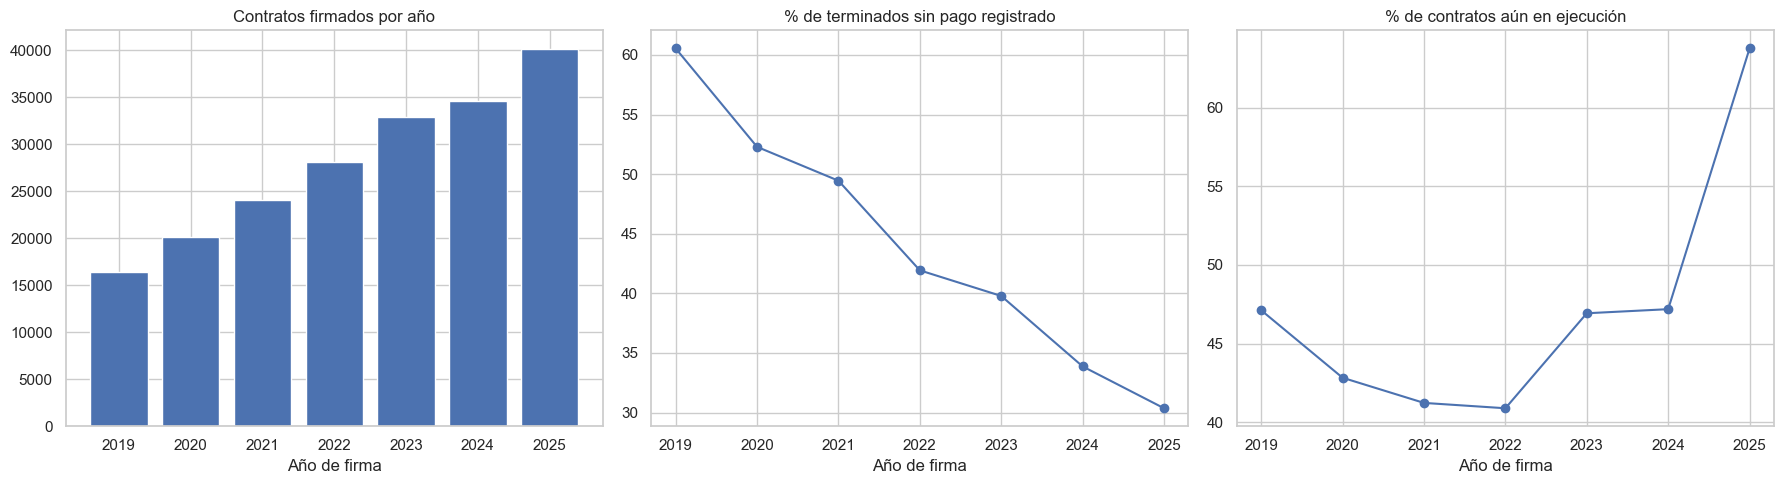

In [25]:
# gráficas de los indicadores por año
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(por_anio.index, por_anio["contratos"])
axes[0].set_title("Contratos firmados por año")
axes[0].set_xlabel("Año de firma")

axes[1].plot(por_anio.index, por_anio["sin_registro_pago"], marker="o")
axes[1].set_title("% de terminados sin pago registrado")
axes[1].set_xlabel("Año de firma")

axes[2].plot(por_anio.index, por_anio["aun_en_curso"], marker="o")
axes[2].set_title("% de contratos aún en ejecución")
axes[2].set_xlabel("Año de firma")

plt.tight_layout()
plt.show()

En los primeros años muchos terminados no tienen pago registrado (60,55% en 2019), y en 2025 el 63,77% de los contratos sigue en ejecución. Por eso, para subejecución usamos solo terminados firmados entre 2021 y 2024. Para la adición de plazo usamos todos los años porque el dato se registra aunque el contrato siga abierto.

In [26]:
# base de terminados 2021-2024 para el análisis de ejecución
df_ejec = df[
    df["ejecucion_terminada"]
    & df["anio_firma"].between(2021, 2024)
    & df["razon_ejecucion"].notna()
].copy()

print(f"Base para adición de plazo:          {len(df):,}")
print(f"Base para subejecución (2021-2024):  {len(df_ejec):,}")
print(f"Tasa de adición:      {100 * df['adicion_plazo'].mean():.2f}%")
print(f"Tasa de subejecución: {100 * df_ejec['subejecucion'].mean():.2f}%")

Base para adición de plazo:          196,199
Base para subejecución (2021-2024):  39,208
Tasa de adición:      9.51%
Tasa de subejecución: 9.22%


### 3.3 Hipótesis 1: modalidad y adición de plazo

- H0: la adición de plazo es independiente de la modalidad de contratación.
- H1: la adición de plazo depende de la modalidad.
- Nivel de significancia: 0,05.

Usamos chi-cuadrado porque las dos variables son categóricas.

In [27]:
# tabla de contingencia y chi-cuadrado (revisamos las frecuencias esperadas)
tabla_h1 = pd.crosstab(df["modalidad_de_contratacion"], df["adicion_plazo"])
chi2, p_h1, gl, esperadas = stats.chi2_contingency(tabla_h1)

print("Frecuencia esperada mínima:", round(esperadas.min(), 1))
print("Celdas con esperada < 5:", (esperadas < 5).sum(), "de", esperadas.size)

Frecuencia esperada mínima: 22.4
Celdas con esperada < 5: 0 de 18


In [28]:
# V de Cramér y tasa de adición por modalidad
n_h1 = tabla_h1.values.sum()
cramer_v = np.sqrt(chi2 / (n_h1 * (min(tabla_h1.shape) - 1)))

tasa_base = df["adicion_plazo"].mean()
tasas_mod = df.groupby("modalidad_de_contratacion")["adicion_plazo"].agg(["size", "mean"])
tasas_mod.columns = ["contratos", "tasa_adicion"]
tasas_mod["veces_base"] = (tasas_mod["tasa_adicion"] / tasa_base).round(2)
tasas_mod["tasa_adicion"] = (100 * tasas_mod["tasa_adicion"]).round(2)
print(tasas_mod.sort_values("tasa_adicion", ascending=False))

print(f"\nTasa base: {100 * tasa_base:.2f}%")
print(f"Chi2 = {chi2:,.1f}, gl = {gl}, p = {p_h1:.3e}")
print(f"V de Cramér = {cramer_v:.4f}")

                                                    contratos  tasa_adicion  \
modalidad_de_contratacion                                                     
Licitación pública                                       2328         25.82   
Seleccion Abreviada Menor Cuantia Sin Manifesta...        235         20.00   
Contratación régimen especial (con ofertas)              6134         18.36   
Selección abreviada subasta inversa                     32900         15.78   
Selección Abreviada de Menor Cuantía                     8817         14.72   
Contratación Directa (con ofertas)                       4995          8.97   
Contratación directa                                     3891          7.63   
Mínima cuantía                                         117685          7.18   
Contratación régimen especial                           19214          6.24   

                                                    veces_base  
modalidad_de_contratacion                                       


Se rechaza H0 (y todas las frecuencias esperadas son mayores a 5). La licitación pública tiene 25,82% de adición, casi tres veces la tasa base (9,51%). Las demás modalidades competitivas también están por encima, y mínima cuantía y régimen especial están por debajo. La V de Cramér es 0,14, un efecto pequeño. Puede que esto pase porque las licitaciones son contratos más grandes, por eso después miramos el valor.

### 3.4 Hipótesis 2: valor del contrato y adición de plazo

- H0: el valor del contrato tiene la misma distribución en contratos con y sin adición.
- H1: las distribuciones son distintas.
- Nivel de significancia: 0,05.

Primero revisamos si el log del valor es normal.

In [29]:
# prueba de normalidad del log del valor en cada grupo
con_adicion = df.loc[df["adicion_plazo"], "valor_del_contrato"]
sin_adicion = df.loc[~df["adicion_plazo"], "valor_del_contrato"]

# normaltest con muestras de 5000, con toda la base cualquier desviación sale significativa
print("Con adición: p =", stats.normaltest(np.log(con_adicion.sample(5000, random_state=42))).pvalue)
print("Sin adición: p =", stats.normaltest(np.log(sin_adicion.sample(5000, random_state=42))).pvalue)

Con adición: p = 1.1326899161935176e-59
Sin adición: p = 3.5107653110681066e-126


No es normal, así que usamos Mann-Whitney.

In [30]:
# prueba de Mann-Whitney y correlación biserial
u_stat, p_mw = stats.mannwhitneyu(con_adicion, sin_adicion, alternative="two-sided")
biserial = 2 * u_stat / (len(con_adicion) * len(sin_adicion)) - 1

print(f"Mediana con adición: {con_adicion.median():,.0f}  (n={len(con_adicion):,})")
print(f"Mediana sin adición: {sin_adicion.median():,.0f}  (n={len(sin_adicion):,})")
print(f"Razón de medianas: {con_adicion.median() / sin_adicion.median():.2f}")
print(f"Mann-Whitney p = {p_mw:.3e}")
print(f"Correlación biserial de rangos = {biserial:.4f}")

Mediana con adición: 86,727,116  (n=18,662)
Mediana sin adición: 30,900,000  (n=177,537)
Razón de medianas: 2.81
Mann-Whitney p = 0.000e+00
Correlación biserial de rangos = 0.3595


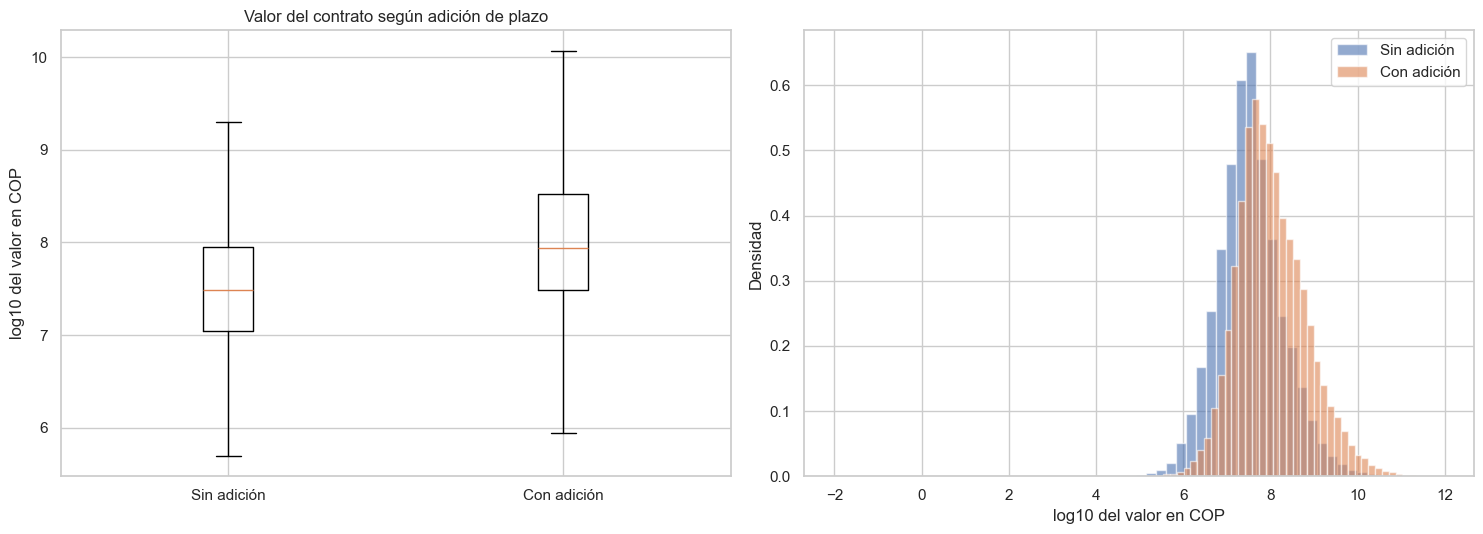

In [31]:
# boxplot e histograma del valor según adición de plazo
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].boxplot([np.log10(sin_adicion), np.log10(con_adicion)],
                tick_labels=["Sin adición", "Con adición"], showfliers=False)
axes[0].set_title("Valor del contrato según adición de plazo")
axes[0].set_ylabel("log10 del valor en COP")

axes[1].hist(np.log10(sin_adicion), bins=60, alpha=0.6, density=True, label="Sin adición")
axes[1].hist(np.log10(con_adicion), bins=60, alpha=0.6, density=True, label="Con adición")
axes[1].set_xlabel("log10 del valor en COP")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.tight_layout()
plt.show()

Se rechaza H0. La mediana con adición es 86,7 millones y sin adición 30,9 millones, casi el triple. La correlación biserial es 0,36 (efecto moderado), mayor que el de la modalidad. Aun así las dos distribuciones se solapan bastante.

### 3.5 Hipótesis 3: ejecución según destino del gasto y sector

- H0: la razón de ejecución (pagado / valor) tiene la misma distribución en todos los grupos.
- H1: al menos un grupo es diferente.
- Nivel de significancia: 0,05.

Usamos solo los terminados de 2021-2024 (`df_ejec`) y revisamos los supuestos de ANOVA.

In [32]:
# supuestos de ANOVA: normalidad y Levene
grupos_dest = [g["razon_ejecucion"].to_numpy() for _, g in df_ejec.groupby("destino_gasto") if len(g) >= 30]

print("Normalidad: p =", stats.normaltest(df_ejec["razon_ejecucion"].sample(5000, random_state=42)).pvalue)
print("Levene:     p =", stats.levene(*grupos_dest, center="median").pvalue)

Normalidad: p = 0.0
Levene:     p = 2.564608529515348e-32


No se cumplen, así que usamos Kruskal-Wallis.

In [33]:
# Kruskal-Wallis y épsilon² por destino del gasto y por sector
def kruskal_con_efecto(grupos):
    h, p = stats.kruskal(*grupos)
    k = len(grupos)
    n = sum(len(g) for g in grupos)
    return h, p, (h - k + 1) / (n - k)


h_dest, p_dest, eps_dest = kruskal_con_efecto(grupos_dest)
print(df_ejec.groupby("destino_gasto").agg(
    contratos=("razon_ejecucion", "size"),
    mediana=("razon_ejecucion", "median"),
    media=("razon_ejecucion", "mean"),
    tasa_subejecucion=("subejecucion", "mean"),
).round(4))
print(f"\nDestino del gasto: H = {h_dest:.2f}, p = {p_dest:.3e}, épsilon² = {eps_dest:.5f}")

grupos_sector = [g["razon_ejecucion"].to_numpy() for _, g in df_ejec.groupby("sector") if len(g) >= 200]
h_sec, p_sec, eps_sec = kruskal_con_efecto(grupos_sector)
print(f"Sector ({len(grupos_sector)} con n >= 200): H = {h_sec:.2f}, p = {p_sec:.3e}, épsilon² = {eps_sec:.5f}")

                contratos  mediana   media  tasa_subejecucion
destino_gasto                                                
Funcionamiento      21005      1.0  0.9618             0.1072
Inversión           18138      1.0  0.9762             0.0746
No Definido            65      1.0  0.9283             0.1538

Destino del gasto: H = 186.53, p = 3.135e-41, épsilon² = 0.00471
Sector (15 con n >= 200): H = 355.77, p = 2.537e-67, épsilon² = 0.00894


Se rechaza H0 en los dos casos, pero el efecto es casi nulo (épsilon² < 0,01) y la mediana de ejecución es 1,00 en todos los grupos. Funcionamiento tiene algo más de subejecución (10,72%) que inversión (7,46%), pero la diferencia es pequeña.

### 3.6 Hipótesis 4: valor y días adicionados

- H0: no hay correlación entre el valor del contrato y los días adicionados.
- H1: sí hay correlación.
- Nivel de significancia: 0,05.

Calculamos Pearson y Spearman con los datos sin limpiar y limpios.

In [34]:
# Pearson y Spearman antes y después de limpiar
r_sucio, p_r_sucio = stats.pearsonr(raw_df["valor_del_contrato"], raw_df["dias_adicionados"])
rho_sucio, p_rho_sucio = stats.spearmanr(raw_df["valor_del_contrato"], raw_df["dias_adicionados"])
r_limpio, p_r_limpio = stats.pearsonr(df["valor_del_contrato"], df["dias_adicionados"])
rho_limpio, p_rho_limpio = stats.spearmanr(df["valor_del_contrato"], df["dias_adicionados"])

print(f"Sin limpiar:  Pearson r = {r_sucio:.4f} (p = {p_r_sucio:.4f})   Spearman rho = {rho_sucio:.4f} (p = {p_rho_sucio:.2e})")
print(f"Limpio:       Pearson r = {r_limpio:.4f} (p = {p_r_limpio:.2e})   Spearman rho = {rho_limpio:.4f} (p = {p_rho_limpio:.2e})")

Sin limpiar:  Pearson r = -0.0003 (p = 0.9016)   Spearman rho = 0.1864 (p = 0.00e+00)
Limpio:       Pearson r = 0.0288 (p = 2.32e-37)   Spearman rho = 0.1864 (p = 0.00e+00)


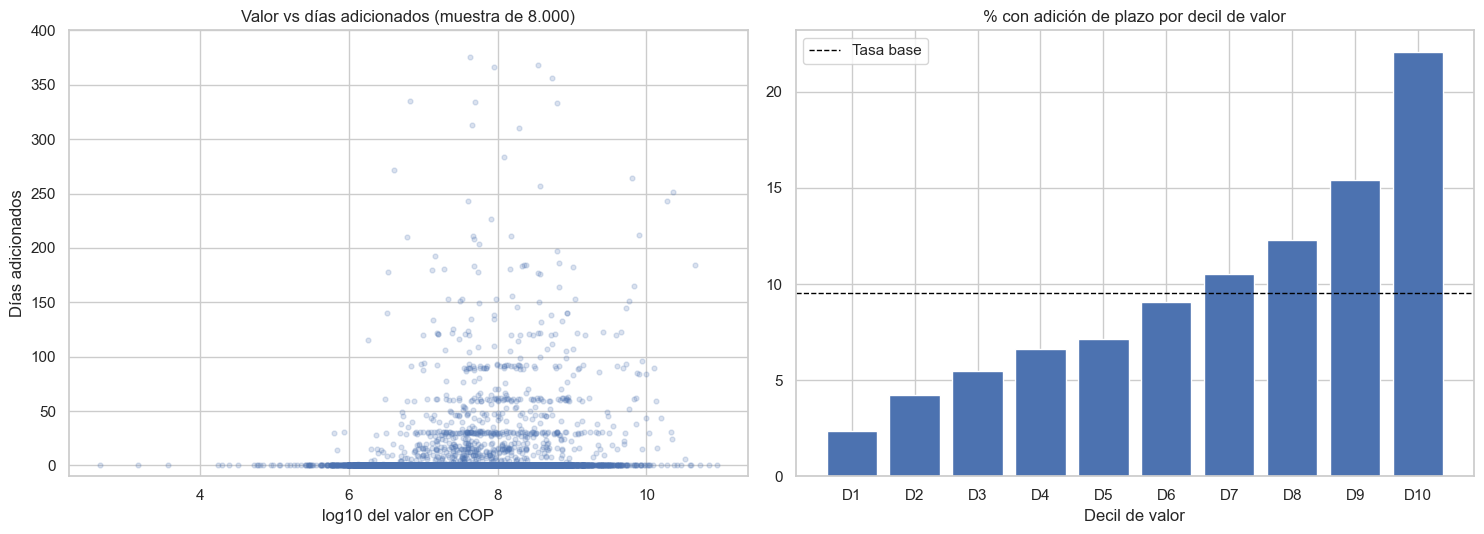

valor_del_contrato
D1      2.34
D2      4.25
D3      5.45
D4      6.64
D5      7.12
D6      9.05
D7     10.50
D8     12.29
D9     15.39
D10    22.09
Name: adicion_plazo, dtype: float64


In [35]:
# scatter de valor vs días y tasa de adición por decil de valor
muestra = df.sample(8000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].scatter(np.log10(muestra["valor_del_contrato"]), muestra["dias_adicionados"], alpha=0.2, s=12)
axes[0].set_title("Valor vs días adicionados (muestra de 8.000)")
axes[0].set_xlabel("log10 del valor en COP")
axes[0].set_ylabel("Días adicionados")
axes[0].set_ylim(-10, 400)

deciles = pd.qcut(df["valor_del_contrato"], 10, labels=[f"D{i}" for i in range(1, 11)])
tasa_decil = df.groupby(deciles, observed=True)["adicion_plazo"].mean() * 100
axes[1].bar(tasa_decil.index.astype(str), tasa_decil.values)
axes[1].axhline(100 * tasa_base, color="black", linestyle="--", linewidth=1, label="Tasa base")
axes[1].set_title("% con adición de plazo por decil de valor")
axes[1].set_xlabel("Decil de valor")
axes[1].legend()

plt.tight_layout()
plt.show()

print(tasa_decil.round(2))

Sin limpiar, Pearson da r = -0,0003 (p = 0,90), así que no se rechaza H0. Con los datos limpios r = 0,029 y sí es significativo: los valores imposibles escondían la relación. Spearman da 0,186 en los dos casos porque no le afectan los extremos.

La relación es débil, pero por deciles se ve clara: la tasa de adición pasa de 2,34% en el decil más bajo a 22,09% en el más alto.

### 3.7 Modalidad y valor juntos

Cruzamos las dos variables para ver si cada una aporta algo por separado.

0.25     12,085,000
0.50     33,680,000
0.75    100,000,000
Name: valor_del_contrato, dtype: object


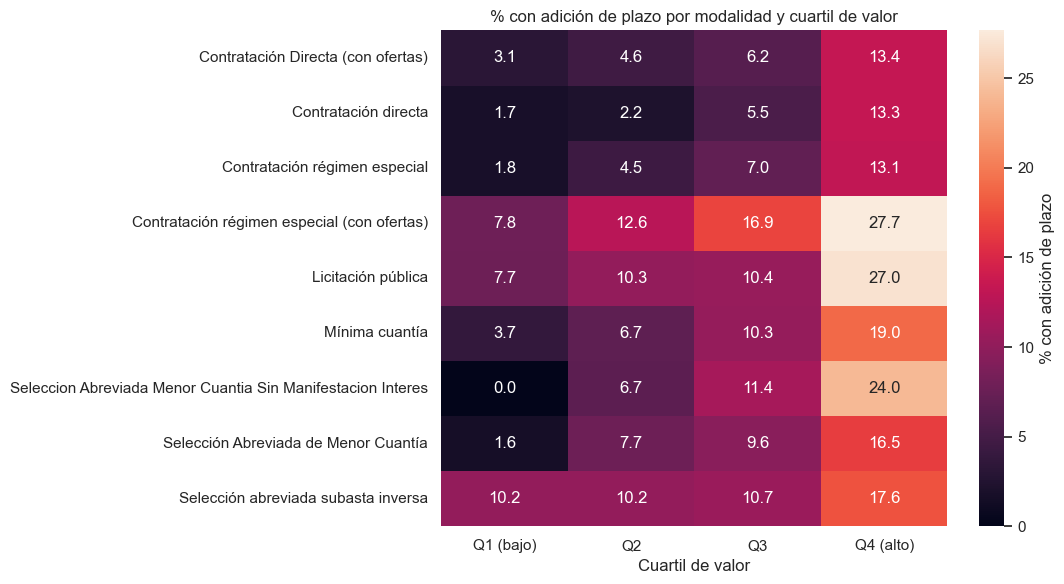

In [36]:
# mapa de calor de adición por modalidad y cuartil de valor
df["cuartil_valor"] = pd.qcut(df["valor_del_contrato"], 4, labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])
print(df["valor_del_contrato"].quantile([0.25, 0.5, 0.75]).map("{:,.0f}".format))

matriz = pd.crosstab(
    df["modalidad_de_contratacion"], df["cuartil_valor"],
    values=df["adicion_plazo"], aggfunc="mean",
) * 100

plt.figure(figsize=(11, 6))
sns.heatmap(matriz, annot=True, fmt=".1f", cbar_kws={"label": "% con adición de plazo"})
plt.title("% con adición de plazo por modalidad y cuartil de valor")
plt.xlabel("Cuartil de valor")
plt.ylabel("")
plt.tight_layout()
plt.show()

Los cortes de los cuartiles son 12 millones, 33,7 millones y 100 millones. En casi todas las modalidades la tasa sube con el valor, y dentro de un mismo cuartil cambia según la modalidad. Por eso tiene sentido usar las dos variables juntas.

**Resumen de las pruebas:**
- Modalidad y adición: significativa, efecto pequeño (V = 0,14).
- Valor y adición: significativa, efecto moderado (biserial = 0,36).
- Ejecución por destino y sector: significativas, pero con efecto casi nulo.
- Pearson valor-días: no significativa sin limpiar (p = 0,90); significativa pero débil con los datos limpios.

## 4. Resultados y recomendaciones

> **Nota:** esta sección resume los resultados. El informe ejecutivo completo (hallazgos, criterios de focalización por niveles, recomendaciones adicionales y limitaciones) está en el archivo `README.md` del repositorio.

### Segmentos para supervisión

Comparamos cinco posibles criterios según su tasa de adición, cuántos contratos incluyen y qué parte del valor total cubren.

In [37]:
# comparamos segmentos candidatos para supervisión
competitivas = [
    "Licitación pública",
    "Contratación régimen especial (con ofertas)",
    "Selección abreviada subasta inversa",
    "Selección Abreviada de Menor Cuantía",
    "Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes",
]

valor_total = df["valor_del_contrato"].sum()
es_competitiva = df["modalidad_de_contratacion"].isin(competitivas)
es_q4 = df["cuartil_valor"] == "Q4 (alto)"

segmentos = {
    "A. Licitación pública": df["modalidad_de_contratacion"] == "Licitación pública",
    "B. Q4 + competitiva + inversión": es_q4 & es_competitiva & (df["destino_gasto"] == "Inversión"),
    "C. Q4 + competitiva": es_q4 & es_competitiva,
    "D. Q4 (cualquier modalidad)": es_q4,
    "E. Competitiva (cualquier valor)": es_competitiva,
}

filas = []
for nombre, mascara in segmentos.items():
    seg = df[mascara]
    filas.append({
        "segmento": nombre,
        "contratos": len(seg),
        "tasa_adicion": round(100 * seg["adicion_plazo"].mean(), 2),
        "veces_base": round(seg["adicion_plazo"].mean() / tasa_base, 2),
        "pct_contratos": round(100 * len(seg) / len(df), 1),
        "pct_valor": round(100 * seg["valor_del_contrato"].sum() / valor_total, 1),
    })

pd.DataFrame(filas).set_index("segmento")

,contratos,tasa_adicion,veces_base,pct_contratos,pct_valor
segmento,,,,,
A. Licitación pública,2328,25.82,2.71,1.2,21.6
B. Q4 + competitiva + inversión,17573,20.26,2.13,9.0,33.1
C. Q4 + competitiva,35792,18.72,1.97,18.2,65.9
D. Q4 (cualquier modalidad),48684,17.76,1.87,24.8,93.1
E. Competitiva (cualquier valor),50414,16.39,1.72,25.7,67.0


### Recomendación

La tasa general de adición de plazo es 9,51%. Recomendamos:

1. **Supervisar todas las licitaciones públicas.** Son el 1,2% de los contratos, cubren el 21,6% del valor y el 25,82% tiene adición.
2. **Si el equipo es pequeño, sumar los contratos de más de 100 millones (Q4) por modalidad competitiva y destino inversión.** Son el 9% de los contratos, cubren el 33,1% del valor y tienen 20,26% de adición.
3. **Si hay más capacidad, incluir todos los Q4 por modalidad competitiva.** Son el 18,2% de los contratos, cubren el 65,9% del valor y tienen 18,72% de adición.

No recomendamos usar el sector o el destino del gasto como criterio principal porque las diferencias son muy pequeñas. También sugerimos revisar el reporte de pagos en SECOP, ya que el 42% de los terminados no tiene pagos registrados.

### Limitaciones

- Los datos los reporta cada entidad y pueden tener errores que no detectamos.
- Una adición de plazo no siempre es una irregularidad.
- El subregistro de pagos limita el análisis de ejecución.
- Los resultados son asociaciones, no causas.
- Los contratos de 2025 todavía pueden cambiar.
- No hicimos un modelo multivariado, solo cruces simples.

### Hallazgos principales

- El valor es el factor más asociado a la adición de plazo (22% en el decil más alto frente a 2% en el más bajo).
- La licitación pública y las demás modalidades competitivas tienen más adiciones que la base.
- Supervisando el 18% de los contratos se cubre el 66% del valor.
- El sector y el destino del gasto no sirven mucho para priorizar.
- La limpieza cambió un resultado: con los valores imposibles, Pearson no mostraba relación entre valor y días adicionados.